In [3]:
# ─────────────────────────────────────────────
# CELL 1 — Imports
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
import tensorflow as tf
import pickle, os, joblib

In [4]:
import pickle


MODEL_PATH = r"GrainD_inverse_model.keras"
inverse_model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

s_X = joblib.load('grainD_inv_scaler_dims.pkl')
s_yt = joblib.load('grainD_inv_scaler_thrust.pkl')
s_yp = joblib.load('grainD_inv_scaler_pressure.pkl')
s_ys = joblib.load('grainD_inv_scaler_scalars.pkl')


  🔩 Predicted Grain-D Dimensions
  Length         : 58.8219 cm
  Diameter       : 13.0757 cm
  Slot_Offset    : 4.3153 cm
  Throat_Diameter: 1.1896 cm
  Exit_Diameter  : 1.8379 cm


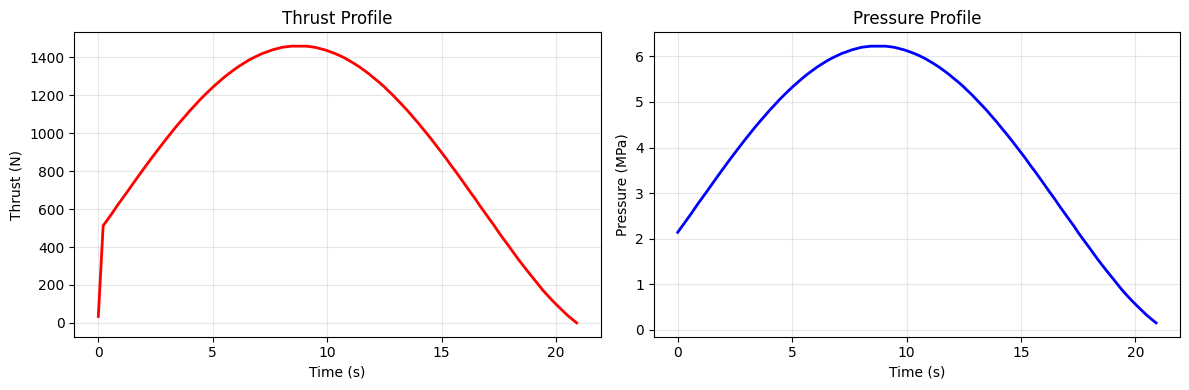

In [6]:
# ══════════════════════════════════════════════════════
# CELL 13 — Inference Function D Grain-D
# ══════════════════════════════════════════════════════
DIM_NAMES = ['Length', 'Diameter', 'Slot_Offset', 'Throat_Diameter', 'Exit_Diameter']
def predict_dimensions_from_file(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    # ── قراءة الملف ──
    if file_path.endswith(('.xlsx', '.xls')):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path, sep=None, engine='python',
                         encoding='latin1', on_bad_lines='skip')

    # ── Smart column detection (نفس BATES) ──
    col_map = {}
    for col in df.columns:
        c = str(col).lower().replace(' ','').replace('_','').replace('(','').replace(')','')
        if 'time' in c:           col_map['time']     = col
        elif 'thrust' in c:       col_map['thrust']   = col
        elif 'pressure' in c:     col_map['pressure'] = col
        elif 'isp' in c:          col_map['isp']      = col

    if not all(k in col_map for k in ['time', 'thrust', 'pressure']):
        raise ValueError(f"Columns not found. Available: {list(df.columns)}")

    df = df.sort_values(col_map['time']).dropna(
        subset=[col_map['time'], col_map['thrust'], col_map['pressure']]
    )

    t        = df[col_map['time']].values.astype(float)
    thrust   = df[col_map['thrust']].values.astype(float)
    pressure = df[col_map['pressure']].values.astype(float)

    if len(thrust) > 7:
        thrust   = savgol_filter(thrust,   window_length=7, polyorder=3)
        pressure = savgol_filter(pressure, window_length=7, polyorder=3)

    x_new        = np.linspace(t[0], t[-1], 100)
    thrust_100   = interp1d(t, thrust,   kind='linear', fill_value='extrapolate')(x_new)
    pressure_100 = interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new)

    burn_time     = t[-1]
    max_thrust    = np.max(thrust)
    total_impulse = np.trapezoid(thrust, t)
    isp           = df[col_map['isp']].iloc[0] if 'isp' in col_map else 220.0

    scalars = np.array([isp, total_impulse, burn_time, max_thrust])

    t_sc = s_yt.transform(thrust_100.reshape(1, -1))
    p_sc = s_yp.transform(pressure_100.reshape(1, -1))
    s_sc = s_ys.transform(scalars.reshape(1, -1))

    pred_sc   = inverse_model.predict([t_sc, p_sc, s_sc], verbose=0)
    pred_dims = s_X.inverse_transform(pred_sc)[0]
    pred_dims = np.maximum(pred_dims, 0.1)

    print("\n" + "="*50)
    print("  🔩 Predicted Grain-D Dimensions")
    print("="*50)
    labels = ['Length         ', 'Diameter       ',
              'Slot_Offset    ', 'Throat_Diameter', 'Exit_Diameter  ']
    for label, val in zip(labels, pred_dims):
        print(f"  {label}: {val:.4f} cm")
    print("="*50)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(x_new, thrust_100,   color='red',  lw=2)
    axes[0].set_title('Thrust Profile'); axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Thrust (N)');    axes[0].grid(True, alpha=0.3)
    axes[1].plot(x_new, pressure_100, color='blue', lw=2)
    axes[1].set_title('Pressure Profile'); axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Pressure (MPa)');  axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    return dict(zip(DIM_NAMES, pred_dims))


# ── تشغيل ──
results = predict_dimensions_from_file(
    '1976.0.xlsx'
)


  🔩 Predicted Grain-D Dimensions
  Length         : 83.0685 cm
  Diameter       : 19.9974 cm
  Slot_Offset    : 8.7611 cm
  Throat_Diameter: 1.4471 cm
  Exit_Diameter  : 2.2456 cm


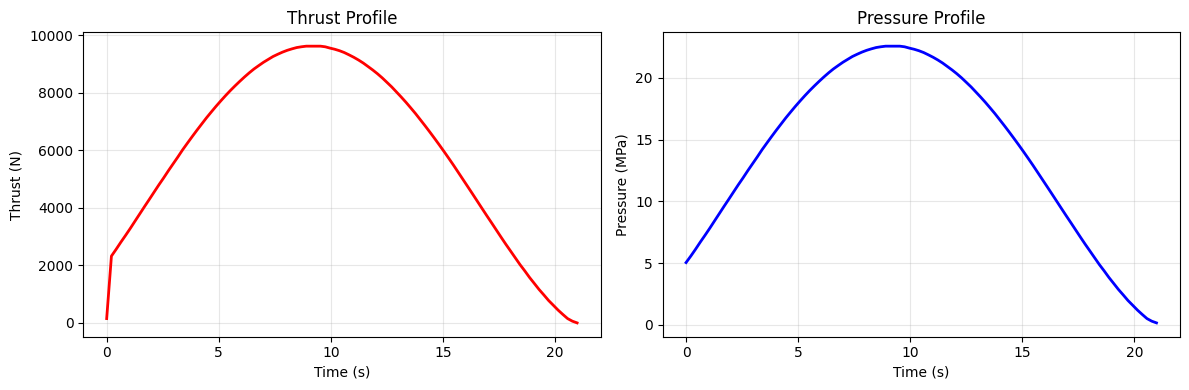

In [7]:
results = predict_dimensions_from_file(
    '3790.0.xlsx'
)